<a href="https://colab.research.google.com/github/NMelbard/PBL1/blob/main/PBL2/pbl2_heparin_exocytosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dH/dt = (heparosan to heparin conversion equation) - vpackaging,hill([H]) - kdegradation*[H]

dR/dt = (1/q)vpackaging,hill([H]) - krelease*[R]

dC/dt = (some time dependent pulse function) - kca*[C]

dV/dt = krelease*[R] - kexo,hill(C)*V

dS/dt = q*kexo,hill(C)*V

Concentrations in terms of mM and time in terms of min

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Let's ignore the signalling cascade and just assume that at fixed intervals something stimulates the gaussian pulse and stimulates the Endoplasmic Reticulum to release calcium.

In [ ]:
t_end = 720 #min
pulse_every = 5 #min
pulse_times = np.arange(5, t_end, pulse_every)

In [ ]:
def v_packaging(H, K, Vmax, n):
  return Vmax * H**n / (K**n + H**n)

def ca_pulse(t, pulse_times, A=1.0, sigma=0.1): #gaussian pulse function
    return sum(
        A * np.exp(-((t - ti)**2) / (2 * sigma**2))
        for ti in pulse_times
    )
def k_exo(C, K, kmax, n):
  return kmax * C**n / (K**n + C**n)

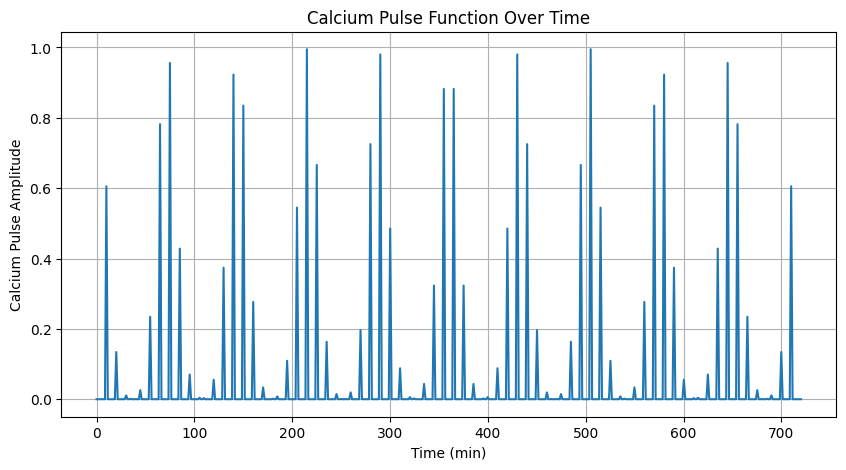

In [ ]:
# Define a time range for plotting the pulse
t_pulse = np.linspace(0, t_end, 500)

# Calculate the calcium pulse values
ca_pulse_values = [ca_pulse(t, pulse_times) for t in t_pulse]

# Plot the calcium pulse
plt.figure(figsize=(10, 5))
plt.plot(t_pulse, ca_pulse_values)
plt.xlabel('Time (min)')
plt.ylabel('Calcium Pulse Amplitude')
plt.title('Calcium Pulse Function Over Time')
plt.grid(True)
plt.show()

In [ ]:
def f_hep(t, y, c, k_sulfation):
  '''
  c = [Kpack, Kexo, Vmax, kmax, n1, n2, kdeg, krel, kca, q, A, sigma]
  '''
  # Unpack state variables: [Heparosan, Heparin, PAPS, Reserve Vesicles, Calcium, Release Vesicles, Secreted Heparin]
  Hs, Hp, PAPS, R, C, V, S = y

  # Heparosan to Heparin conversion rate
  v_sulfation = k_sulfation * Hs * PAPS

  # Unpack parameters from c for clarity and correct indexing
  Kpack, Kexo, Vmax, kmax, n1, n2, kdeg, krel, kca, q, A, sigma = c

  #heparosan-heparin equations from Jacob
  dHs_dt = -v_sulfation
  dHp_dt = v_sulfation - v_packaging(Hp, Kpack, Vmax, n1) - kdeg * Hp
  dPAPS_dt = -v_sulfation

  #exocytosis
  dR_dt = (1/q) * v_packaging(Hp, Kpack, Vmax, n1) - krel * R # Corrected c[8] to q
  dC_dt = ca_pulse(t, pulse_times, A=A, sigma=sigma) - kca * C
  dV_dt = krel * R - k_exo(C, Kexo, kmax, n2) * V # Corrected: multiplied by V
  dS_dt = q * k_exo(C, Kexo, kmax, n2) * V # Corrected: q * (rate) * V

  return [dHs_dt, dHp_dt, dPAPS_dt, dR_dt, dC_dt, dV_dt, dS_dt]

In [ ]:
#parameters (made up, need literature values)
Kpack = 0.1 #affinity constant for packaging heparin (mM)
Kexo = 0.001 #affinity constant for exocytosis process (mM)
Vmax = 0.1 #maximum packaging rate coefficient (mM/min)
kmax = 5.0 #maximum exocytosis rate coefficient (1/min)
n1 = 1 #hill coefficent for heparin packaging
n2 = 2 #hill coefficient for exocytosis
kdeg = 0.05 #heparin degradation coefficient (1/min)
krel = 0.3 #rate of reserve converting to release vesicles coefficient (1/min)
kca = 5.0 #calcium uptake coefficient (1/min)
q = 1e-3 #amount heparin molecules per vesicle (mM)
k_sulfation = 0.05 # lumped reaction rate constant for sulfation (1/(mM*min))
A = 1.0 #max rate of calcium release [Ca]/min
sigma = 0.1 #controls width of the gaussian pulse

In [ ]:
c = [Kpack, Kexo, Vmax, kmax, n1, n2, kdeg, krel, kca, q, A, sigma]

# Initial conditions for [Hs, Hp, PAPS, R, C, V, S]
# Using initial conditions from the sulfation model (Hs0, Hp0, PAPS0) and existing exocytosis model
Hs0 = 10.0    # initial heparosan (from sulfation model)
Hp0 = 0.0     # initial heparin (from sulfation model, and H in exocytosis)
PAPS0 = 12.0  # initial PAPS (from sulfation model)
R0 = 90.0     # initial R (from existing exocytosis model in y_init)
C0 = 0.0      # initial C (from existing exocytosis model in y_init)
V0 = 10.0     # initial V (from existing exocytosis model in y_init)
S0 = 0.0      # initial S (from existing exocytosis model in y_init)

y_init = [Hs0, Hp0, PAPS0, R0, C0, V0, S0]

tspan = np.linspace(0, t_end, 1000)
sol = solve_ivp(lambda t, y: f_hep(t, y, c, k_sulfation), [tspan[0], tspan[-1]], y_init, t_eval=tspan)
print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  7.207e-01 ...  7.193e+02  7.200e+02]
        y: [[ 1.000e+01  6.903e+00 ...  9.642e-32  8.972e-32]
            [ 0.000e+00  2.972e+00 ...  1.015e-32  9.444e-33]
            ...
            [ 1.000e+01  3.375e+01 ...  5.645e-29  6.709e-29]
            [ 0.000e+00  3.040e-272 ...  3.973e+00  3.973e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 19124
     njev: 0
      nlu: 0


In [ ]:
eqs = ["Heparosan", "Heparin", "PAPS", "Reserve Vesicles", "Calcium", "Ready Vesicles", "Exported Heparin"]

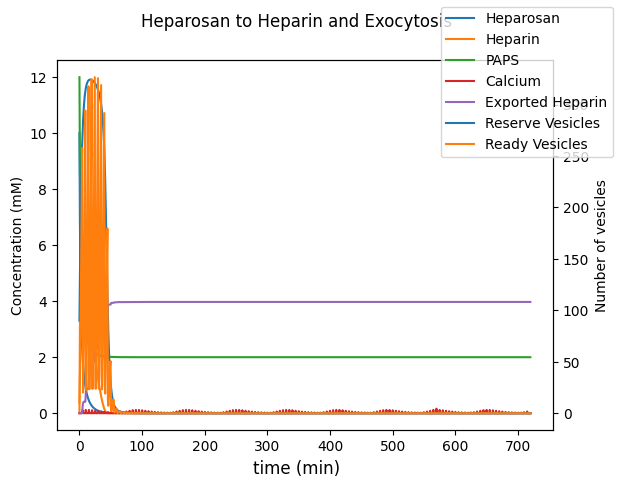

<Figure size 2400x1200 with 0 Axes>

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

plt.figure(figsize=(8,4),dpi=300)
for i, s in enumerate(sol.y):
  if eqs[i] in ["Reserve Vesicles", "Ready Vesicles"]:
    ax2.plot(sol.t, s, label=eqs[i])
  else:
    ax1.plot(sol.t, s, label=eqs[i])

fig.supxlabel('time (min)')
ax1.set_ylabel('Concentration (mM)')
ax2.set_ylabel('Number of vesicles')
fig.legend()
fig.suptitle('Heparosan to Heparin and Exocytosis')
plt.show()

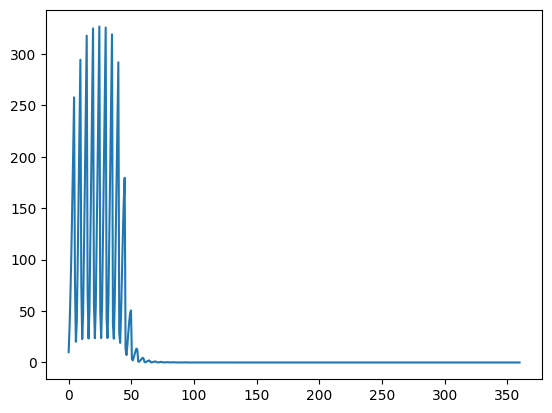

In [ ]:
stop = 500
plt.plot(sol.t[:stop], sol.y[5][:stop])